#### Problem Statement
##### Monitor Urban Traffic
##### Detect Congestion and Incidents Early
##### Support Emergency Response and Traffic Control Decisions
##### Current Problems Faced
##### Manual traffic monitoring is slow and inefficient
##### CCTV and aerial footage are not analyzed intelligently
##### Traffic congestion is detected too late
##### No data-driven visualization for quick decision-making
##### Core Need
##### Analyze aerial imagery–derived traffic data
##### Automatically detect congestion or incidents
##### Provide visual risk maps for decision-makers

#### Tools & Technologies Used
#### Programming Language: Python 3.14.2
#### Environment: Jupyter Notebook
#### Libraries Used
#### pandas
#### numpy
#### matplotlib
#### seaborn
#### scikit-learn

#### 1.Load and Inspect the Dataset

In [2]:
import numpy as np 
import pandas as pd
df=pd.read_csv("D:\\data E\\New Volume\\Python programming tutorials\\TIhan-IIT-MASAI\\Traffic Congestion - Sheet1.csv")
print("display the data frame")
df
#display first 5 rows
print("Displays first 5 rows")
df.head()
print("Display information")
df.info()
print("Describe information")
df.describe()

display the data frame
Displays first 5 rows
Display information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vehicle_density    4000 non-null   float64
 1   avg_vehicle_speed  4000 non-null   float64
 2   speed_std          4000 non-null   float64
 3   lane_occupancy     4000 non-null   float64
 4   queue_length       4000 non-null   float64
 5   edge_density       4000 non-null   float64
 6   optical_flow_mag   4000 non-null   float64
 7   shadow_fraction    4000 non-null   float64
 8   time_of_day_norm   4000 non-null   float64
 9   road_width_norm    4000 non-null   float64
 10  label              4000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 343.9 KB
Describe information


,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,label
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,20.116392,55.895658,6.351934,0.335010,7.959204,0.401409,0.560445,0.150426,0.497673,0.699993,0.450000
std,12.604460,16.584939,4.384556,0.209370,5.666685,0.135858,0.182694,0.078367,0.289784,0.172762,0.497556
min,0.326223,5.000000,0.002577,0.000000,0.109818,0.124681,0.000000,0.000000,0.000094,0.400063,0.000000
25%,10.933062,46.412276,2.939375,0.181017,3.922624,0.303003,0.453835,0.094160,0.241122,0.549426,0.000000
50%,17.535134,57.994579,5.780743,0.297576,6.521932,0.378663,0.576044,0.148212,0.495915,0.701816,0.000000
75%,26.604050,67.643562,8.810003,0.453174,10.463889,0.475957,0.691486,0.202875,0.752959,0.845197,1.000000
max,116.858197,90.000000,37.937951,1.000000,43.285818,1.000000,1.000000,0.493909,0.999957,0.999905,1.000000


#### 2.Feature Understanding
#### vehicle_density → Vehicles per tile → High density = traffic jam
#### avg_vehicle_speed → Mean speed → Low speed = congestion
#### lane_occupancy → Percentage of lane used → Saturation indicator
#### queue_length → Stopped vehicle line → Incident indicator
#### optical_flow → Motion magnitude → Low motion = blockage
#### edge_density → Structural clutter → Congested patterns
#### time_of_day → Normalized time → Peak congestion patterns

In [27]:
df['tile_x'] = df.index % 10
df['tile_y'] = df.index // 10
df['prediction'] = model.predict(X_scaled)


#### 3.Data Cleaning Preprocessing

In [5]:
import numpy as np 
import pandas as pd
df=pd.read_csv("D:\\data E\\New Volume\\Python programming tutorials\\TIhan-IIT-MASAI\\Traffic Congestion - Sheet1.csv")
print("display the data frame")
df
df=df.dropna()
df=df.drop_duplicates()

display the data frame


#### 4.Label Encoding

In [7]:
from sklearn.preprocessing import LabelEncoder
a=LabelEncoder()
df['label']=a.fit_transform(df['label'])
df['label'].value_counts()
a.classes_

array([0, 1])

##### 5.Exploratory Data Analysis
##### Feature Distribution

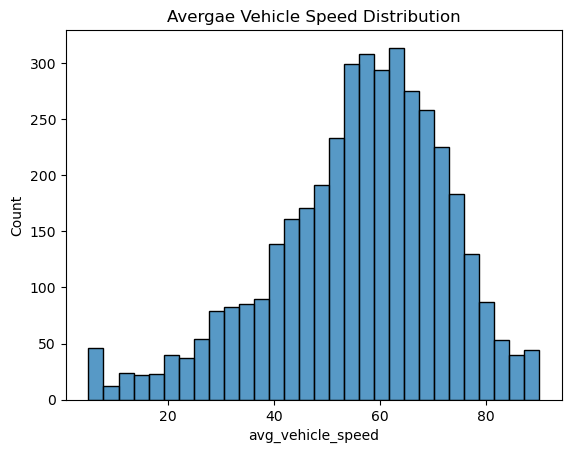

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['avg_vehicle_speed'],bins=30)
plt.title("Avergae Vehicle Speed Distribution")
plt.show()

#### Co Relation Analysis


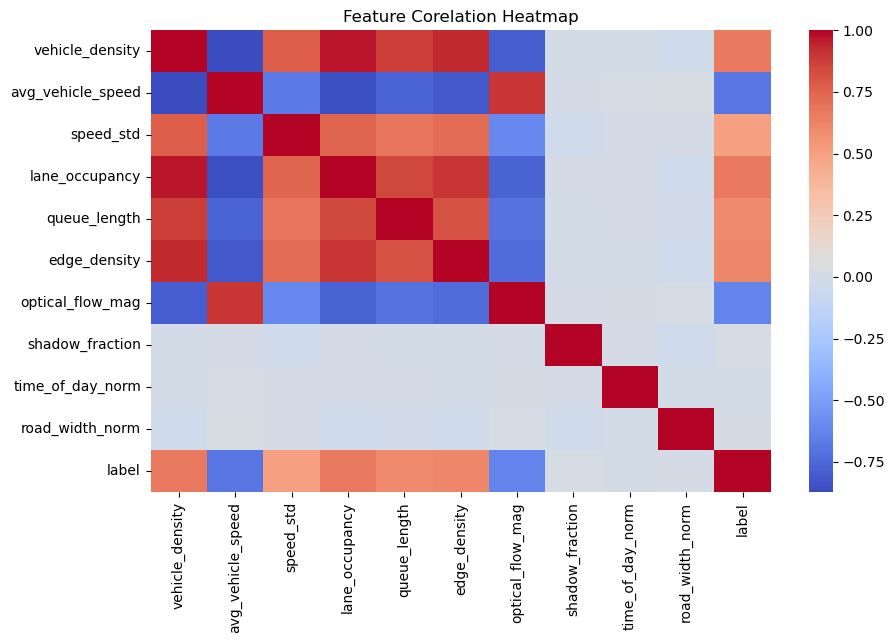

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm",annot=False)
plt.title("Feature Corelation Heatmap")
plt.show()

#### Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler
X=df.drop('label',axis=1)
y=df['label']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#### Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(
    X_scaled ,y,test_size=0.2,random_state=42
)

#### Machine Learning Model

In [20]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Model Evaluation

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)[:, 1]
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("ROC-AUC :", roc_auc_score(y_test,y_prob))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88       443
           1       0.88      0.79      0.83       357

    accuracy                           0.86       800
   macro avg       0.86      0.85      0.85       800
weighted avg       0.86      0.86      0.86       800

[[403  40]
 [ 75 282]]
ROC-AUC : 0.9325834171140237


#### Spatial Aggregation & Traffic Heatmap

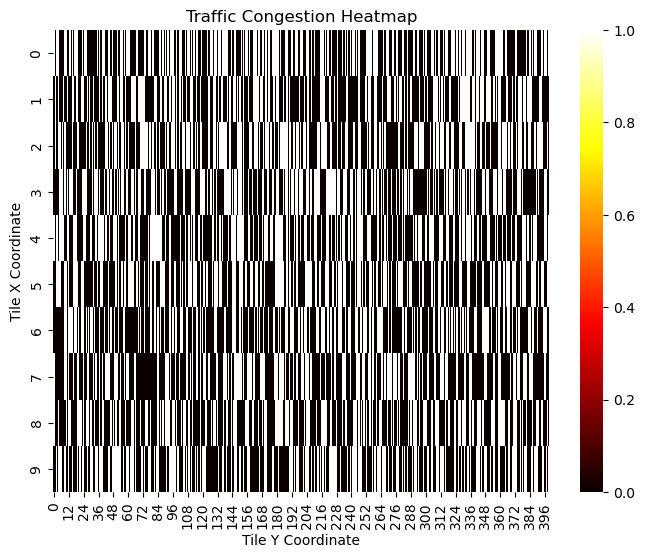

In [28]:
df['prediction'] = model.predict(X_scaled)

heatmap_data = (
    df.groupby(['tile_x', 'tile_y'])['prediction']
    .mean()
    .unstack()
)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap='hot')
plt.title("Traffic Congestion Heatmap")
plt.xlabel("Tile Y Coordinate")
plt.ylabel("Tile X Coordinate")
plt.show()


In [25]:
print(df.columns)

Index(['vehicle_density', 'avg_vehicle_speed', 'speed_std', 'lane_occupancy',
       'queue_length', 'edge_density', 'optical_flow_mag', 'shadow_fraction',
       'time_of_day_norm', 'road_width_norm', 'label', 'prediction'],
      dtype='object')
